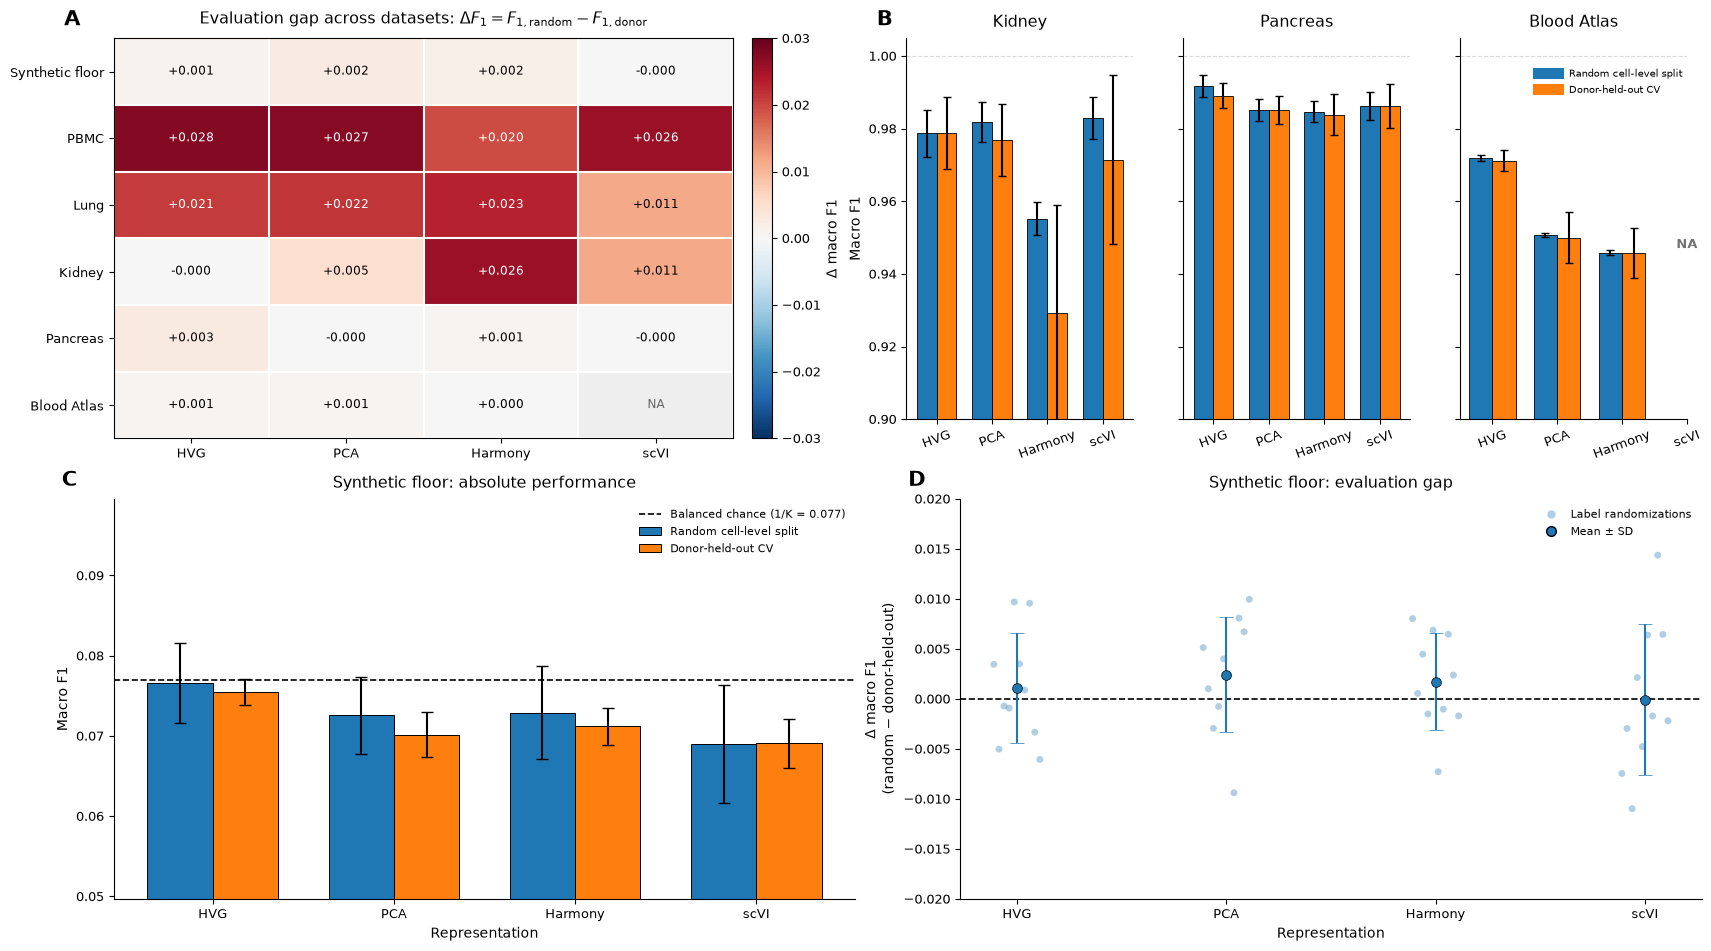

In [7]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D


# ============================================================
# 1. Locate repository
# ============================================================

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "src" / "scrna_benchmark").is_dir():
            return p

    raise RuntimeError(
        "Run this notebook from somewhere inside the repository."
    )


REPO_ROOT = find_repo_root()

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(
        0,
        str(REPO_ROOT / "src"),
    )


# ============================================================
# 2. Paths
# ============================================================

RESULT_DIRS = {
    "PBMC": (
        REPO_ROOT
        / "results/pbmc_no_batch"
    ),
    "Lung": (
        REPO_ROOT
        / "results/lung_no_batch_L4"
    ),
    "Kidney": (
        REPO_ROOT
        / "results/kidney_no_batch"
    ),
    "Pancreas": (
        REPO_ROOT
        / "results/pancreas_no_batch"
    ),
    "Blood Atlas": (
        REPO_ROOT
        / "results/blood_atlas_no_batch"
    ),
}

SYNTHETIC_DIR = (
    REPO_ROOT
    / "results/synthetic_floor"
)

SYNTHETIC_REPLICATES_PATH = (
    SYNTHETIC_DIR
    / "null_control_replicates.csv"
)

SYNTHETIC_DELTAS_PATH = (
    SYNTHETIC_DIR
    / "null_control_deltas.csv"
)

SYNTHETIC_CONFIG_PATH = (
    SYNTHETIC_DIR
    / "config.json"
)

FIG_DIR = (
    REPO_ROOT
    / "manuscript_figures"
)


# ============================================================
# 3. Validate required files
# ============================================================

required = [
    SYNTHETIC_REPLICATES_PATH,
    SYNTHETIC_DELTAS_PATH,
    SYNTHETIC_CONFIG_PATH,
]

for dataset, result_dir in RESULT_DIRS.items():

    required.extend([
        result_dir
        / "random_split"
        / "random_split_repeated_metrics.csv",

        result_dir
        / "donor_cv"
        / "metrics.csv",
    ])


missing = [
    p for p in required
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required Figure 4 inputs:\n"
        + "\n".join(str(p) for p in missing)
    )


# ============================================================
# 4. Representation definitions
# ============================================================

REP_ORDER = [
    "hvg",
    "pca",
    "harmony",
    "scvi",
]

REP_LABELS = {
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
}


# ============================================================
# 5. Helper: load biological dataset evaluation summaries
# ============================================================

def load_evaluation_summary(result_dir):

    random_df = pd.read_csv(
        result_dir
        / "random_split"
        / "random_split_repeated_metrics.csv"
    )

    donor_df = pd.read_csv(
        result_dir
        / "donor_cv"
        / "metrics.csv"
    )

    random_summary = (
        random_df
        .groupby("representation")["macro_f1"]
        .agg(["mean", "std"])
    )

    donor_summary = (
        donor_df
        .set_index("representation")
    )

    available = [
        rep
        for rep in REP_ORDER
        if (
            rep in random_summary.index
            and rep in donor_summary.index
        )
    ]

    random_summary = (
        random_summary
        .reindex(available)
    )

    donor_summary = (
        donor_summary
        .reindex(available)
    )

    delta = (
        random_summary["mean"]
        - donor_summary["macro_f1_mean"]
    )

    return (
        random_summary,
        donor_summary,
        delta,
    )


# ============================================================
# 6. Load all biological datasets
# ============================================================

BIO_SUMMARIES = {}

for dataset, result_dir in RESULT_DIRS.items():

    (
        random_summary,
        donor_summary,
        delta,
    ) = load_evaluation_summary(
        result_dir
    )

    BIO_SUMMARIES[dataset] = {
        "random": random_summary,
        "donor": donor_summary,
        "delta": delta,
    }


# ============================================================
# 7. Load synthetic floor outputs
# ============================================================

synthetic_replicates = pd.read_csv(
    SYNTHETIC_REPLICATES_PATH
)

synthetic_deltas = pd.read_csv(
    SYNTHETIC_DELTAS_PATH
)

with open(
    SYNTHETIC_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as handle:

    synthetic_config = json.load(
        handle
    )


chance_macro_f1 = float(
    synthetic_config[
        "chance_macro_f1"
    ]
)


synthetic_scheme_summary = (
    synthetic_replicates
    .groupby(
        [
            "representation",
            "scheme",
        ]
    )["macro_f1_mean"]
    .agg(
        ["mean", "std"]
    )
    .reset_index()
)


synthetic_random = (
    synthetic_scheme_summary[
        synthetic_scheme_summary[
            "scheme"
        ].eq("random_split")
    ]
    .set_index("representation")
    .reindex(REP_ORDER)
)


synthetic_donor = (
    synthetic_scheme_summary[
        synthetic_scheme_summary[
            "scheme"
        ].eq("donor_cv")
    ]
    .set_index("representation")
    .reindex(REP_ORDER)
)


synthetic_delta_mean = (
    synthetic_deltas
    .groupby("representation")[
        "delta_macro_f1"
    ]
    .mean()
    .reindex(REP_ORDER)
)


# ============================================================
# 8. Cross-dataset heatmap matrix
# ============================================================

DATASET_ORDER = [
    "Synthetic floor",
    "PBMC",
    "Lung",
    "Kidney",
    "Pancreas",
    "Blood Atlas",
]


heatmap = pd.DataFrame(
    index=DATASET_ORDER,
    columns=REP_ORDER,
    dtype=float,
)


heatmap.loc[
    "Synthetic floor",
    REP_ORDER,
] = synthetic_delta_mean.to_numpy()


for dataset in [
    "PBMC",
    "Lung",
    "Kidney",
    "Pancreas",
    "Blood Atlas",
]:

    delta = BIO_SUMMARIES[
        dataset
    ]["delta"]

    for rep in delta.index:

        heatmap.loc[
            dataset,
            rep,
        ] = delta.loc[
            rep
        ]


# Blood Atlas has no scVI representation.
heatmap.loc[
    "Blood Atlas",
    "scvi",
] = np.nan


# ============================================================
# 9. Styling
# ============================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
})


BLUE = "#1f77b4"
ORANGE = "#ff7f0e"
GRAY = "#666666"
LIGHT_GRAY = "#eeeeee"


def clean_axis(ax):

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)


def panel_letter(
    ax,
    letter,
    x=-0.08,
    y=1.03,
):

    ax.text(
        x,
        y,
        letter,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )


# ============================================================
# 10. Figure layout
# ============================================================

fig = plt.figure(
    figsize=(17, 9.4),
    layout="constrained",
)

outer = fig.add_gridspec(
    2,
    14,
    height_ratios=[
        1.0,
        1.0,
    ],
)


# Panel A
axA = fig.add_subplot(
    outer[
        0,
        0:6,
    ]
)


# Panel B: three aligned ceiling small multiples
gsB = (
    outer[
        0,
        6:14,
    ]
    .subgridspec(
        1,
        3,
        wspace=0.08,
    )
)


axB1 = fig.add_subplot(
    gsB[
        0,
        0,
    ]
)

axB2 = fig.add_subplot(
    gsB[
        0,
        1,
    ],
    sharey=axB1,
)

axB3 = fig.add_subplot(
    gsB[
        0,
        2,
    ],
    sharey=axB1,
)


# Bottom row
axC = fig.add_subplot(
    outer[
        1,
        0:7,
    ]
)

axD = fig.add_subplot(
    outer[
        1,
        7:14,
    ]
)


# ============================================================
# A. Cross-dataset ΔF1 heatmap
# ============================================================

panel_letter(
    axA,
    "A",
    x=-0.08,
    y=1.02,
)


heat_values = (
    heatmap
    .to_numpy(
        dtype=float
    )
)


observed_abs = np.nanmax(
    np.abs(
        heat_values
    )
)

heat_abs = max(
    0.03,
    float(
        observed_abs
    ),
)


norm = TwoSlopeNorm(
    vmin=-heat_abs,
    vcenter=0,
    vmax=heat_abs,
)


cmap = plt.get_cmap(
    "RdBu_r"
).copy()

cmap.set_bad(
    color=LIGHT_GRAY
)


masked = np.ma.masked_invalid(
    heat_values
)


im = axA.imshow(
    masked,
    aspect="auto",
    cmap=cmap,
    norm=norm,
)


axA.set_xticks(
    np.arange(
        len(REP_ORDER)
    ),
    [
        REP_LABELS[r]
        for r in REP_ORDER
    ],
)


axA.set_yticks(
    np.arange(
        len(DATASET_ORDER)
    ),
    DATASET_ORDER,
)


axA.set_title(
    r"Evaluation gap across datasets: "
    r"$\Delta F_1 = F_{1,\mathrm{random}} - F_{1,\mathrm{donor}}$",
    pad=10,
)


# Cell annotations
for i in range(
    len(DATASET_ORDER)
):

    for j in range(
        len(REP_ORDER)
    ):

        value = heat_values[
            i,
            j,
        ]

        if np.isnan(
            value
        ):

            text = "NA"
            text_color = "0.4"

        else:

            text = (
                f"{value:+.3f}"
            )

            text_color = (
                "white"
                if abs(value)
                > 0.55 * heat_abs
                else "black"
            )


        axA.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize=8.5,
            color=text_color,
        )


# Thin internal grid
axA.set_xticks(
    np.arange(
        -0.5,
        len(REP_ORDER),
        1,
    ),
    minor=True,
)

axA.set_yticks(
    np.arange(
        -0.5,
        len(DATASET_ORDER),
        1,
    ),
    minor=True,
)

axA.grid(
    which="minor",
    color="white",
    linewidth=1.5,
)

axA.tick_params(
    which="minor",
    bottom=False,
    left=False,
)


# Colorbar
cbar = fig.colorbar(
    im,
    ax=axA,
    fraction=0.046,
    pad=0.03,
)

cbar.set_label(
    r"$\Delta$ macro F1"
)


# ============================================================
# B. Ceiling datasets
# ============================================================

panel_letter(
    axB1,
    "B",
    x=-0.13,
    y=1.02,
)


CEILING_DATASETS = [
    (
        "Kidney",
        axB1,
    ),
    (
        "Pancreas",
        axB2,
    ),
    (
        "Blood Atlas",
        axB3,
    ),
]


x = np.arange(
    len(REP_ORDER)
)

bar_width = 0.36


for dataset, ax in CEILING_DATASETS:

    random_summary = (
        BIO_SUMMARIES[
            dataset
        ]["random"]
    )

    donor_summary = (
        BIO_SUMMARIES[
            dataset
        ]["donor"]
    )


    for j, rep in enumerate(
        REP_ORDER
    ):

        # Explicit NA for unavailable representations.
        if (
            rep
            not in random_summary.index
            or rep
            not in donor_summary.index
        ):

            ax.text(
                j,
                0.948,
                "NA",
                ha="center",
                va="center",
                fontsize=9,
                color="0.45",
                fontweight="bold",
            )

            continue


        random_mean = (
            random_summary.loc[
                rep,
                "mean",
            ]
        )

        random_sd = (
            random_summary.loc[
                rep,
                "std",
            ]
        )


        donor_mean = (
            donor_summary.loc[
                rep,
                "macro_f1_mean",
            ]
        )

        donor_sd = (
            donor_summary.loc[
                rep,
                "macro_f1_std",
            ]
        )


        ax.bar(
            j - bar_width / 2,
            random_mean,
            width=bar_width,
            yerr=random_sd,
            capsize=3,
            color=BLUE,
            edgecolor="black",
            linewidth=0.6,
        )


        ax.bar(
            j + bar_width / 2,
            donor_mean,
            width=bar_width,
            yerr=donor_sd,
            capsize=3,
            color=ORANGE,
            edgecolor="black",
            linewidth=0.6,
        )


    ax.set_xticks(
        x,
        [
            REP_LABELS[r]
            for r in REP_ORDER
        ],
        rotation=20,
    )


    ax.set_title(
        dataset,
        pad=8,
    )


    # Same y-scale across all ceiling datasets.
    ax.set_ylim(
        0.90,
        1.005,
    )


    clean_axis(
        ax
    )


# Only first subplot needs y-axis title.
axB1.set_ylabel(
    "Macro F1"
)


# Hide repeated y-axis labels.
axB2.tick_params(
    axis="y",
    labelleft=False,
)

axB3.tick_params(
    axis="y",
    labelleft=False,
)


# Reference line at perfect classification.
for ax in [
    axB1,
    axB2,
    axB3,
]:

    ax.axhline(
        1.0,
        color="0.85",
        linestyle="--",
        linewidth=0.8,
        zorder=0,
    )


# ============================================================
# Panel B legend
#
# Use the naturally open upper-right region of the Blood Atlas
# panel, above the unavailable scVI category.
# ============================================================

handles_B = [
    Line2D(
        [0],
        [0],
        color=BLUE,
        linewidth=8,
        label="Random cell-level split",
    ),

    Line2D(
        [0],
        [0],
        color=ORANGE,
        linewidth=8,
        label="Donor-held-out CV",
    ),
]


axB3.legend(
    handles=handles_B,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(
        1.00,
        0.93, 
    ),
    ncol=1,
    fontsize=7.5,
    handlelength=2.0,
    handletextpad=1.0,   
    labelspacing=0.55, 
    borderaxespad=0.0,
)


# ============================================================
# C. Synthetic floor: absolute macro-F1
# ============================================================

panel_letter(
    axC,
    "C",
    x=-0.07,
    y=1.02,
)


x = np.arange(
    len(REP_ORDER)
)

bar_width = 0.36


axC.bar(
    x - bar_width / 2,
    synthetic_random[
        "mean"
    ].to_numpy(),
    width=bar_width,
    yerr=synthetic_random[
        "std"
    ].to_numpy(),
    capsize=4,
    color=BLUE,
    edgecolor="black",
    linewidth=0.7,
    label="Random cell-level split",
)


axC.bar(
    x + bar_width / 2,
    synthetic_donor[
        "mean"
    ].to_numpy(),
    width=bar_width,
    yerr=synthetic_donor[
        "std"
    ].to_numpy(),
    capsize=4,
    color=ORANGE,
    edgecolor="black",
    linewidth=0.7,
    label="Donor-held-out CV",
)


axC.axhline(
    chance_macro_f1,
    linestyle="--",
    linewidth=1.2,
    color="black",
    label=(
        "Balanced chance "
        f"(1/K = {chance_macro_f1:.3f})"
    ),
)


axC.set_xticks(
    x,
    [
        REP_LABELS[r]
        for r in REP_ORDER
    ],
)


axC.set_xlabel(
    "Representation"
)

axC.set_ylabel(
    "Macro F1"
)

axC.set_title(
    "Synthetic floor: absolute performance",
    pad=8,
)


# Focus the scale around the floor.
synthetic_low = np.nanmin(
    np.concatenate([
        (
            synthetic_random["mean"]
            - synthetic_random["std"]
        ).to_numpy(),

        (
            synthetic_donor["mean"]
            - synthetic_donor["std"]
        ).to_numpy(),

        np.array([
            chance_macro_f1
        ]),
    ])
)


synthetic_high = np.nanmax(
    np.concatenate([
        (
            synthetic_random["mean"]
            + synthetic_random["std"]
        ).to_numpy(),

        (
            synthetic_donor["mean"]
            + synthetic_donor["std"]
        ).to_numpy(),

        np.array([
            chance_macro_f1
        ]),
    ])
)


axC.set_ylim(
    max(
        0,
        synthetic_low - 0.012,
    ),
    synthetic_high + 0.018,
)


axC.legend(
    frameon=False,
    loc="upper right",
    fontsize=8,
)


clean_axis(
    axC
)


# ============================================================
# D. Synthetic paired ΔF1 distribution
# ============================================================

panel_letter(
    axD,
    "D",
    x=-0.07,
    y=1.02,
)


x = np.arange(
    len(REP_ORDER)
)


for i, rep in enumerate(
    REP_ORDER
):

    vals = (
        synthetic_deltas.loc[
            synthetic_deltas[
                "representation"
            ].eq(rep),
            "delta_macro_f1",
        ]
        .dropna()
        .to_numpy()
    )


    # Deterministic horizontal spread.
    if len(vals) > 1:

        offsets = np.linspace(
            -0.11,
            0.11,
            len(vals),
        )

    else:

        offsets = np.array([
            0.0
        ])


    axD.scatter(
        i + offsets,
        vals,
        s=25,
        alpha=0.35,
        color=BLUE,
        edgecolor="none",
        zorder=2,
    )


    mean = np.mean(
        vals
    )

    sd = np.std(
        vals,
        ddof=1,
    )


    axD.errorbar(
        i,
        mean,
        yerr=sd,
        fmt="o",
        markersize=7,
        capsize=5,
        linewidth=1.5,
        color=BLUE,
        markeredgecolor="black",
        markeredgewidth=0.5,
        zorder=4,
    )


axD.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="black",
)


axD.set_xticks(
    x,
    [
        REP_LABELS[r]
        for r in REP_ORDER
    ],
)


axD.set_xlabel(
    "Representation"
)

axD.set_ylabel(
    r"$\Delta$ macro F1"
    "\n(random − donor-held-out)"
)

axD.set_title(
    "Synthetic floor: evaluation gap",
    pad=8,
)


max_abs_delta = max(
    0.02,
    float(
        np.nanmax(
            np.abs(
                synthetic_deltas[
                    "delta_macro_f1"
                ]
            )
        )
    )
    + 0.004,
)


axD.set_ylim(
    -max_abs_delta,
    max_abs_delta,
)


handles_D = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=BLUE,
        markeredgecolor="none",
        alpha=0.35,
        markersize=6,
        label="Label randomizations",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=BLUE,
        markeredgecolor="black",
        markersize=7,
        label="Mean ± SD",
    ),
]


axD.legend(
    handles=handles_D,
    frameon=False,
    loc="upper right",
    fontsize=8,
)


clean_axis(
    axD
)


# ============================================================
# Display only for now
# ============================================================

# out_png = FIG_DIR / "figure4_boundary_conditions.png"
# out_pdf = FIG_DIR / "figure4_boundary_conditions.pdf"

# fig.savefig(
#     out_png,
#     dpi=300,
#     bbox_inches="tight",
# )

# fig.savefig(
#     out_pdf,
#     bbox_inches="tight",
# )

plt.show()